# Hybrid Retrieval Evaluation (eval.json only)

Pipeline:
1. Dense retrieval (BGE-M3)
2. BM25 retrieval
3. RRF fusion
4. Optional rerank
5. Evaluate hit@k and recall@k on eval.json


## 0) Cai thu vien (Colab)

In [1]:
# Colab deps (run once), then Runtime -> Restart runtime
!pip -q uninstall -y torchao
!pip install -q --upgrade pip
!pip install -q "transformers>=4.53.3" "accelerate>=0.33.0" sentencepiece torch tqdm rank-bm25 ftfy underthesea pyvi
!pip install -q faiss-cpu


## 1) Config (Local + Colab)

In [2]:
from __future__ import annotations

import json
import os
import re
import unicodedata
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Set

import numpy as np
import torch
import torch.nn.functional as F
from rank_bm25 import BM25Okapi
from tqdm.auto import tqdm

try:
    from ftfy import fix_text
except Exception:
    def fix_text(x: str) -> str:
        return x

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_PROJECT_ROOT = '/content/drive/MyDrive/RAG'
    drive.mount('/content/drive', force_remount=False)
    ROOT = Path(DRIVE_PROJECT_ROOT)
else:
    ROOT = Path('.')

JD_JSON_PATH = ROOT / 'jd_full_text.json'
JD_EMB_PATH = ROOT / 'jd_embeddings.npz'
QUERY_EVAL_PATH = ROOT / 'eval.json'
FAISS_INDEX_PATH = ROOT / 'faiss_jd_dense_v2.index'
if QUERY_EVAL_PATH.name != 'eval.json':
    raise ValueError('This notebook is configured to use eval.json only.')

DENSE_MODEL_ID = 'AITeamVN/Vietnamese_Embedding_v2'
RERANKER_MODEL_ID = 'BAAI/bge-reranker-v2-m3'

DENSE_TOP_K = 50
BM25_TOP_K = 50
FUSION_TOP_K = 50
FINAL_TOP_K = 10
RRF_K = 60

BATCH_SIZE = 16
MAX_LENGTH = 512
MAX_RERANK_LEN = 1024
HF_CACHE = str((ROOT / 'hf_cache').resolve())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.environ['HF_HOME'] = HF_CACHE
os.environ['HUGGINGFACE_HUB_CACHE'] = HF_CACHE
os.environ['HF_HUB_CACHE'] = HF_CACHE
os.environ['TRANSFORMERS_CACHE'] = HF_CACHE
os.environ['HF_DATASETS_CACHE'] = HF_CACHE
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

def normalize_text(text: str) -> str:
    text = '' if text is None else str(text)
    text = fix_text(text)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

VN_TOKENIZER = 'regex'
try:
    from underthesea import word_tokenize as uts_word_tokenize
    def vi_word_tokenize(text: str) -> List[str]:
        return [t for t in uts_word_tokenize(text, format='text').split() if t]
    VN_TOKENIZER = 'underthesea'
except Exception:
    try:
        from pyvi import ViTokenizer
        def vi_word_tokenize(text: str) -> List[str]:
            return [t.replace('_', ' ') for t in ViTokenizer.tokenize(text).split() if t]
        VN_TOKENIZER = 'pyvi'
    except Exception:
        TOKEN_RE = re.compile(r'\w+', flags=re.UNICODE)
        def vi_word_tokenize(text: str) -> List[str]:
            return TOKEN_RE.findall(text.lower())

print('IN_COLAB =', IN_COLAB)
print('ROOT =', ROOT.resolve() if ROOT.exists() else ROOT)
print('DEVICE =', DEVICE)
print('QUERY_EVAL_PATH =', QUERY_EVAL_PATH)
print('DENSE_MODEL_ID =', DENSE_MODEL_ID)
print('VN_TOKENIZER =', VN_TOKENIZER)
for req in [JD_JSON_PATH, JD_EMB_PATH, QUERY_EVAL_PATH]:
    print(f'{req}:', 'OK' if req.exists() else 'MISSING')

print('FAISS_INDEX_PATH =', FAISS_INDEX_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB = True
ROOT = /content/drive/MyDrive/RAG
DEVICE = cuda
QUERY_EVAL_PATH = /content/drive/MyDrive/RAG/eval.json
DENSE_MODEL_ID = AITeamVN/Vietnamese_Embedding_v2
VN_TOKENIZER = underthesea
/content/drive/MyDrive/RAG/jd_full_text.json: OK
/content/drive/MyDrive/RAG/jd_embeddings.npz: OK
/content/drive/MyDrive/RAG/eval.json: OK
FAISS_INDEX_PATH = /content/drive/MyDrive/RAG/faiss_jd_dense_v2.index


## 2) Load du lieu JD + dense embeddings

In [3]:
with JD_JSON_PATH.open('r', encoding='utf-8') as f:
    jd_raw = json.load(f)

emb_npz = np.load(JD_EMB_PATH, allow_pickle=True)
doc_embs = emb_npz['embeddings'].astype(np.float32)
doc_embs /= np.linalg.norm(doc_embs, axis=1, keepdims=True) + 1e-12
doc_ids = [str(x) for x in emb_npz['jd_ids']]
doc_texts = [normalize_text(str(x)) for x in emb_npz['texts']]
doc_id_to_index = {doc_id: i for i, doc_id in enumerate(doc_ids)}

# jd_full_text.json can be list[dict] with fields like jd_id/full_text/rag_text/header/company
meta_by_id = {}
if isinstance(jd_raw, list):
    for jd in jd_raw:
        if not isinstance(jd, dict):
            continue
        jid = str(jd.get('jd_id', '')).strip()
        if not jid:
            continue
        header = jd.get('header') or {}
        meta_by_id[jid] = {
            'company': normalize_text(jd.get('company', '')),
            'title': normalize_text(header.get('title', jd.get('title', ''))),
            'city': normalize_text(header.get('city', jd.get('city', ''))),
        }

print('Num docs:', len(doc_ids))
print('Embedding shape:', doc_embs.shape)


Num docs: 580
Embedding shape: (580, 1024)


## 2b) Build and Save FAISS index (dense_v2 vectors)

In [4]:
import faiss

# Build FAISS with precomputed dense vectors from jd_embeddings.npz (normalized)
faiss_index = faiss.IndexFlatIP(doc_embs.shape[1])
faiss_index.add(doc_embs.astype(np.float32))
faiss.write_index(faiss_index, str(FAISS_INDEX_PATH))
print('Saved FAISS index:', FAISS_INDEX_PATH)
print('FAISS ntotal:', faiss_index.ntotal)


Saved FAISS index: /content/drive/MyDrive/RAG/faiss_jd_dense_v2.index
FAISS ntotal: 580


## 3) Build BM25 index

In [5]:
def simple_tokenize(text: str) -> List[str]:
    text = normalize_text(text).lower()
    return vi_word_tokenize(text)

corpus_tokens = [simple_tokenize(t) for t in doc_texts]
bm25 = BM25Okapi(corpus_tokens)

print('BM25 ready with', len(corpus_tokens), 'documents')
print('Tokenizer backend:', VN_TOKENIZER)


BM25 ready with 580 documents
Tokenizer backend: underthesea


## 4) Load Dense Encoder + Reranker

In [6]:
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer

dense_tokenizer = AutoTokenizer.from_pretrained(DENSE_MODEL_ID, cache_dir=HF_CACHE)
dense_model = AutoModel.from_pretrained(DENSE_MODEL_ID, cache_dir=HF_CACHE).to(DEVICE).eval()

rerank_tokenizer = AutoTokenizer.from_pretrained(RERANKER_MODEL_ID, cache_dir=HF_CACHE)
rerank_model = AutoModelForSequenceClassification.from_pretrained(RERANKER_MODEL_ID, cache_dir=HF_CACHE).to(DEVICE).eval()

print('Loaded dense model:', DENSE_MODEL_ID)
print('Loaded reranker:', RERANKER_MODEL_ID)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loaded dense model: AITeamVN/Vietnamese_Embedding_v2
Loaded reranker: BAAI/bge-reranker-v2-m3


## 5) Retrieval + Fusion + Rerank

In [7]:
@torch.no_grad()
def encode_queries(texts: List[str], batch_size: int = BATCH_SIZE) -> np.ndarray:
    texts = [normalize_text(t) for t in texts]
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = dense_tokenizer(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt').to(DEVICE)
        out = dense_model(**enc, return_dict=True)
        cls = F.normalize(out.last_hidden_state[:, 0], p=2, dim=-1)
        all_vecs.append(cls.detach().cpu().numpy().astype(np.float32))
    return np.concatenate(all_vecs, axis=0)

def dense_v2_search(query: str, top_k: int = DENSE_TOP_K):
    q = encode_queries([normalize_text(query)]).astype(np.float32)

    # Prefer saved FAISS index when available
    global faiss_index
    try:
        _ = faiss_index
    except NameError:
        import faiss
        if FAISS_INDEX_PATH.exists():
            faiss_index = faiss.read_index(str(FAISS_INDEX_PATH))
        else:
            faiss_index = faiss.IndexFlatIP(doc_embs.shape[1])
            faiss_index.add(doc_embs.astype(np.float32))

    scores, idx = faiss_index.search(q, top_k)
    return [(doc_ids[i], float(scores[0][r]), int(r + 1)) for r, i in enumerate(idx[0])]

def bm25_search(query: str, top_k: int = BM25_TOP_K):
    toks = simple_tokenize(query)
    scores = bm25.get_scores(toks)
    idx = np.argpartition(-scores, top_k - 1)[:top_k]
    idx = idx[np.argsort(-scores[idx])]
    return [(doc_ids[i], float(scores[i]), int(rank + 1)) for rank, i in enumerate(idx)]

def rrf_fusion(result_lists: List[List[tuple]], k: int = RRF_K):
    fused = defaultdict(float)
    for results in result_lists:
        for doc_id, _score, rank in results:
            fused[doc_id] += 1.0 / (k + rank)
    return sorted(fused.items(), key=lambda x: x[1], reverse=True)

@torch.no_grad()
def rerank_candidates(query: str, candidate_doc_ids: List[str], top_k: int = FINAL_TOP_K):
    query = normalize_text(query)
    valid_ids = [x for x in candidate_doc_ids if x in doc_id_to_index]
    pairs = [[query, doc_texts[doc_id_to_index[doc_id]]] for doc_id in valid_ids]
    enc = rerank_tokenizer(pairs, padding=True, truncation=True, max_length=MAX_RERANK_LEN, return_tensors='pt').to(DEVICE)
    scores = rerank_model(**enc, return_dict=True).logits.view(-1).detach().cpu().numpy().astype(float)
    ranked_idx = np.argsort(-scores)
    ranked = [(valid_ids[i], float(scores[i])) for i in ranked_idx]
    return ranked[:top_k], ranked

def hybrid_retrieve_no_rerank(query: str, top_k: int = FINAL_TOP_K):
    dense_res = dense_v2_search(query, top_k=DENSE_TOP_K)
    bm25_res = bm25_search(query, top_k=BM25_TOP_K)
    fused = rrf_fusion([dense_res, bm25_res], k=RRF_K)
    return [doc_id for doc_id, _ in fused[:top_k]]

def hybrid_retrieve_with_rerank(query: str, top_k: int = FINAL_TOP_K):
    dense_res = dense_v2_search(query, top_k=DENSE_TOP_K)
    bm25_res = bm25_search(query, top_k=BM25_TOP_K)
    fused = rrf_fusion([dense_res, bm25_res], k=RRF_K)
    candidates = [doc_id for doc_id, _ in fused[:FUSION_TOP_K]]
    topk, _all = rerank_candidates(query, candidates, top_k=top_k)
    return [doc_id for doc_id, _ in topk]


## 6) Demo query

In [8]:
# demo_query = 'ung vien co kinh nghiem React va Node.js'
# print('Dense v2:', dense_only_ranked_ids(demo_query, 5))
# print('BM25:', bm25_only_ranked_ids(demo_query, 5))
# print('Hybrid no rerank:', hybrid_no_rerank_ranked_ids(demo_query, 5))
# print('Hybrid rerank:', hybrid_rerank_ranked_ids(demo_query, 5))


## 7) Eval functions for eval.json

In [9]:
def load_eval_rows(path: Path):
    if path.name != 'eval.json':
        raise ValueError(f'Expected eval.json, got: {path}')
    data = json.loads(path.read_text(encoding='utf-8'))
    if not isinstance(data, dict) or 'entries' not in data:
        raise ValueError('Invalid eval.json schema. Expected top-level object with entries[].')
    entries = data.get('entries', [])
    rows = []
    for item in entries:
        if not isinstance(item, dict):
            continue
        q = normalize_text(item.get('query', ''))
        gts = [str(x).strip() for x in item.get('ground_truth_jd_ids', []) if str(x).strip()]
        if q and gts:
            rows.append({'id': item.get('id', ''), 'type': item.get('type', 'unknown'), 'split': item.get('split', 'unknown'), 'query': q, 'relevant_jd_ids': set(gts)})
    return rows

def mean_or_zero(vals):
    return float(np.mean(vals)) if vals else 0.0

def dense_only_ranked_ids(query: str, top_k: int):
    return [doc_id for doc_id, _s, _r in dense_v2_search(query, top_k=top_k)]

def bm25_only_ranked_ids(query: str, top_k: int):
    return [doc_id for doc_id, _s, _r in bm25_search(query, top_k=top_k)]

def hybrid_no_rerank_ranked_ids(query: str, top_k: int):
    dense_res = dense_v2_search(query, top_k=max(DENSE_TOP_K, top_k))
    bm25_res = bm25_search(query, top_k=max(BM25_TOP_K, top_k))
    fused = rrf_fusion([dense_res, bm25_res], k=RRF_K)
    return [doc_id for doc_id, _ in fused[:top_k]]

def hybrid_rerank_ranked_ids(query: str, top_k: int):
    return hybrid_retrieve_with_rerank(query, top_k=top_k)

def rank_docs_by_system(query: str, system_name: str, top_k: int):
    if system_name == 'dense_v2_only':
        return dense_only_ranked_ids(query, top_k)
    if system_name == 'bm25_only':
        return bm25_only_ranked_ids(query, top_k)
    if system_name == 'hybrid_rrf_no_rerank':
        return hybrid_no_rerank_ranked_ids(query, top_k)
    if system_name == 'hybrid_rrf_rerank':
        return hybrid_rerank_ranked_ids(query, top_k)
    raise ValueError(f'Unknown system: {system_name}')

def eval_rows(rows, system_name: str, top_ks=(1, 5, 10)):
    scores = defaultdict(list)
    max_k = max(top_ks)
    for row in tqdm(rows, desc=f'Evaluating {system_name}'):
        ranked = rank_docs_by_system(row['query'], system_name, max_k)
        rel = row['relevant_jd_ids']
        for k in top_ks:
            preds = ranked[:k]
            hit = 1.0 if any(x in rel for x in preds) else 0.0
            rec = len([x for x in preds if x in rel]) / max(len(rel), 1)
            scores[f'hit@{k}'].append(hit)
            scores[f'recall@{k}'].append(rec)
    return {k: round(mean_or_zero(v), 6) for k, v in sorted(scores.items())}


## 8) Run eval and save

In [10]:
rows = load_eval_rows(QUERY_EVAL_PATH)
print('Num eval queries:', len(rows))

OUTPUT_PATH = ROOT / 'query_retrieval_eval.json'
saved = json.loads(OUTPUT_PATH.read_text(encoding='utf-8')) if OUTPUT_PATH.exists() else {}

systems_to_run = ['dense_v2_only', 'bm25_only', 'hybrid_rrf_no_rerank', 'hybrid_rrf_rerank']
existing = saved.get('systems') or {}
results = {}
for name in systems_to_run:
    if name in existing:
        print('Load existing metrics:', name)
        results[name] = existing[name]
    else:
        print('Run fresh eval:', name)
        results[name] = eval_rows(rows, name, top_ks=(1, 5, 10))

out = dict(saved)
out['num_queries'] = len(rows)
out['num_jds'] = len(doc_ids)
out['eval_source'] = str(QUERY_EVAL_PATH)
out['systems'] = dict(existing)
out['systems'].update(results)
OUTPUT_PATH.write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding='utf-8')
print('Saved:', OUTPUT_PATH)
print(json.dumps(results, ensure_ascii=False, indent=2))


Num eval queries: 847
Run fresh eval: dense_v2_only


Evaluating dense_v2_only:   0%|          | 0/847 [00:00<?, ?it/s]

Run fresh eval: bm25_only


Evaluating bm25_only:   0%|          | 0/847 [00:00<?, ?it/s]

Run fresh eval: hybrid_rrf_no_rerank


Evaluating hybrid_rrf_no_rerank:   0%|          | 0/847 [00:00<?, ?it/s]

Run fresh eval: hybrid_rrf_rerank


Evaluating hybrid_rrf_rerank:   0%|          | 0/847 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/RAG/query_retrieval_eval.json
{
  "dense_v2_only": {
    "hit@1": 0.330579,
    "hit@10": 0.590319,
    "hit@5": 0.5183,
    "recall@1": 0.26588,
    "recall@10": 0.453938,
    "recall@5": 0.406522
  },
  "bm25_only": {
    "hit@1": 0.319953,
    "hit@10": 0.591499,
    "hit@5": 0.508855,
    "recall@1": 0.249536,
    "recall@10": 0.434416,
    "recall@5": 0.374335
  },
  "hybrid_rrf_no_rerank": {
    "hit@1": 0.38843,
    "hit@10": 0.680047,
    "hit@5": 0.583235,
    "recall@1": 0.29512,
    "recall@10": 0.496511,
    "recall@5": 0.434047
  },
  "hybrid_rrf_rerank": {
    "hit@1": 0.459268,
    "hit@10": 0.752066,
    "hit@5": 0.694215,
    "recall@1": 0.343894,
    "recall@10": 0.546104,
    "recall@5": 0.510089
  }
}


## 9) Bang so sanh nhanh

In [11]:
import pandas as pd

saved = json.loads((ROOT / 'query_retrieval_eval.json').read_text(encoding='utf-8'))
systems = saved.get('systems', {})

rows_table = []
for name, m in systems.items():
    rows_table.append({
        'system': name,
        'hit@1': m.get('hit@1', None),
        'hit@5': m.get('hit@5', None),
        'hit@10': m.get('hit@10', None),
        'recall@1': m.get('recall@1', None),
        'recall@5': m.get('recall@5', None),
        'recall@10': m.get('recall@10', None),
    })

df_compare = pd.DataFrame(rows_table)
if not df_compare.empty:
    df_compare = df_compare.sort_values(by='hit@10', ascending=False).reset_index(drop=True)

display(df_compare)


,system,hit@1,hit@5,hit@10,recall@1,recall@5,recall@10
0,hybrid_rrf_rerank,0.459268,0.694215,0.752066,0.343894,0.510089,0.546104
1,hybrid_rrf_no_rerank,0.388430,0.583235,0.680047,0.295120,0.434047,0.496511
2,bm25_only,0.319953,0.508855,0.591499,0.249536,0.374335,0.434416
3,dense_v2_only,0.330579,0.518300,0.590319,0.265880,0.406522,0.453938


## 10) Lay top-5 context cho LLM (hybrid khong rerank)

In [12]:
def build_context_for_llm(query: str, top_k: int = 5) -> str:
    top_ids = hybrid_retrieve_no_rerank(query, top_k=top_k)
    parts = []
    for i, doc_id in enumerate(top_ids, 1):
        meta = meta_by_id.get(doc_id, {})
        text = doc_texts[doc_id_to_index[doc_id]]
        block = (
            f"[Doc {i}]\n"
            f"jd_id: {doc_id}\n"
            f"title: {meta.get('title', '')}\n"
            f"company: {meta.get('company', '')}\n"
            f"city: {meta.get('city', '')}\n"
            f"content: {text}\n"
        )
        parts.append(block)
    return '\n'.join(parts)

query = 'can ung vien Python backend 3 nam kinh nghiem'
context = build_context_for_llm(query, top_k=5)
print(context[:3000])


[Doc 1]
jd_id: JD-0048
title: IT Developer (Backend .NET)
company: Modern System VN
city: Bắc Ninh
content: Công ty Modern System VN tuyển IT Developer (Backend .NET) level Junior, Middle tại Bắc Ninh. Yêu cầu 1 năm, 3 năm kinh nghiệm. Kỹ năng: C#, .NET, Restful Api. Deadline: 07-05-2026.

[Doc 2]
jd_id: JD-0001
title: Backend Developer
company: CÔNG TY TNHH KAMEREO
city: Hồ Chí Minh
content: Công ty CÔNG TY TNHH KAMEREO tuyển Backend Developer level Middle tại Hồ Chí Minh. Yêu cầu 3 năm kinh nghiệm. Kỹ năng: Minimum 3 years of experience in Java/Kotlin, Proficiency in MySQL and database optimization, Strong understanding of RESTful APIs and microservices, Experience with Spring Boot, Proficient in Git and CI/CD processes, Problem-solving and analytical thinking skills. Ưu tiên: Cloud technologies (AWS, GCP, Azure), Docker and Kubernetes, GraphQL / gRPC, Elasticsearch, MongoDB. Phúc lợi: Competitive salary with 100% probation pay and annual reviews, plus performance-based bonuses and p

## 11) Ve bieu do metric bang Matplotlib

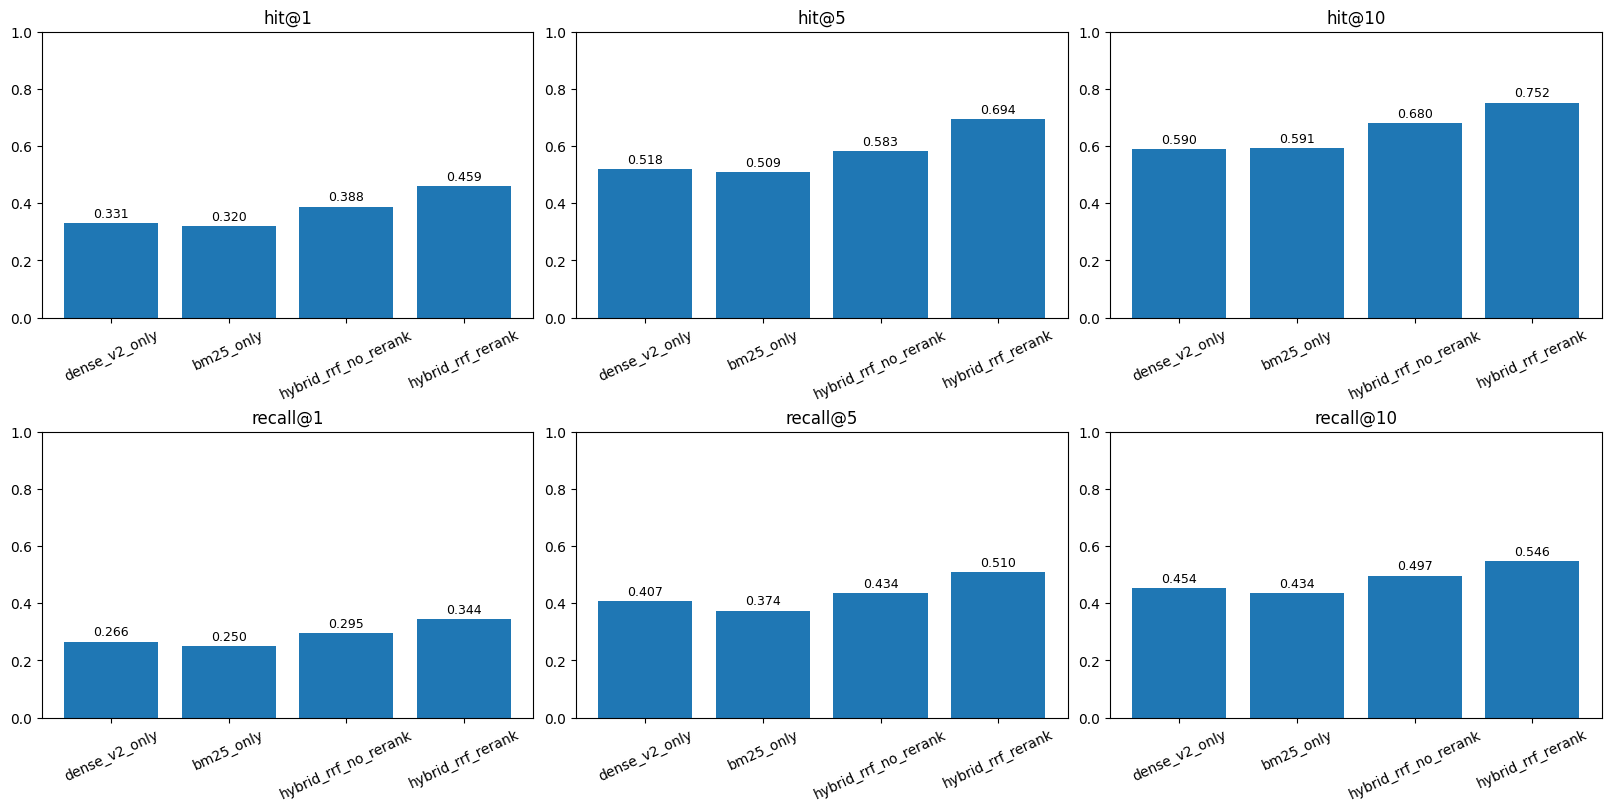

In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt

result_path = ROOT / 'query_retrieval_eval.json'
saved = json.loads(result_path.read_text(encoding='utf-8'))
systems = saved.get('systems', {})

if not systems:
    raise ValueError('Khong c? d? li?u systems trong query_retrieval_eval.json')

system_names = list(systems.keys())
metrics = ['hit@1', 'hit@5', 'hit@10', 'recall@1', 'recall@5', 'recall@10']

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
axes = axes.flatten()

for i, metric in enumerate(metrics):
    vals = [systems.get(name, {}).get(metric, np.nan) for name in system_names]
    ax = axes[i]
    bars = ax.bar(system_names, vals)
    ax.set_title(metric)
    ax.set_ylim(0.0, 1.0)
    ax.tick_params(axis='x', rotation=25)

    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.show()


## 12) Danh gia theo split (test / val / train)

In [14]:
# split eval
TARGET_SPLIT = 'test'
rows_all = load_eval_rows(QUERY_EVAL_PATH)
rows_split = [r for r in rows_all if str(r.get('split', '')).lower() == TARGET_SPLIT.lower()]
print(f'Num {TARGET_SPLIT} queries:', len(rows_split))
if not rows_split:
    raise ValueError(f'No rows for split={TARGET_SPLIT}')

OUTPUT_PATH = ROOT / 'query_retrieval_eval.json'
saved = json.loads(OUTPUT_PATH.read_text(encoding='utf-8')) if OUTPUT_PATH.exists() else {}
systems_to_run = ['dense_v2_only', 'bm25_only', 'hybrid_rrf_no_rerank', 'hybrid_rrf_rerank']
existing_split = ((saved.get('splits') or {}).get(TARGET_SPLIT) or {})
results_split = {}
for name in systems_to_run:
    if name in existing_split:
        print('Load existing split metrics:', name)
        results_split[name] = existing_split[name]
    else:
        print('Run fresh split eval:', name)
        results_split[name] = eval_rows(rows_split, name, top_ks=(1,5,10))
out = dict(saved)
out.setdefault('splits', {})
out['splits'].setdefault(TARGET_SPLIT, {})
out['splits'][TARGET_SPLIT].update(results_split)
out[f'num_{TARGET_SPLIT}_queries'] = len(rows_split)
OUTPUT_PATH.write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(results_split, ensure_ascii=False, indent=2))


Num test queries: 72
Run fresh split eval: dense_v2_only


Evaluating dense_v2_only:   0%|          | 0/72 [00:00<?, ?it/s]

Run fresh split eval: bm25_only


Evaluating bm25_only:   0%|          | 0/72 [00:00<?, ?it/s]

Run fresh split eval: hybrid_rrf_no_rerank


Evaluating hybrid_rrf_no_rerank:   0%|          | 0/72 [00:00<?, ?it/s]

Run fresh split eval: hybrid_rrf_rerank


Evaluating hybrid_rrf_rerank:   0%|          | 0/72 [00:00<?, ?it/s]

{
  "dense_v2_only": {
    "hit@1": 0.138889,
    "hit@10": 0.208333,
    "hit@5": 0.208333,
    "recall@1": 0.125,
    "recall@10": 0.201389,
    "recall@5": 0.194444
  },
  "bm25_only": {
    "hit@1": 0.125,
    "hit@10": 0.166667,
    "hit@5": 0.125,
    "recall@1": 0.111111,
    "recall@10": 0.159722,
    "recall@5": 0.118056
  },
  "hybrid_rrf_no_rerank": {
    "hit@1": 0.138889,
    "hit@10": 0.208333,
    "hit@5": 0.194444,
    "recall@1": 0.125,
    "recall@10": 0.208333,
    "recall@5": 0.194444
  },
  "hybrid_rrf_rerank": {
    "hit@1": 0.166667,
    "hit@10": 0.236111,
    "hit@5": 0.222222,
    "recall@1": 0.152778,
    "recall@10": 0.229167,
    "recall@5": 0.215278
  }
}
